In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt

In [3]:

env = gym.make("CarRacing-v3", render_mode="rgb_array", lap_complete_percent=0.95, domain_randomize=False, continuous=False)
env

<TimeLimit<OrderEnforcing<PassiveEnvChecker<CarRacing<CarRacing-v3>>>>>

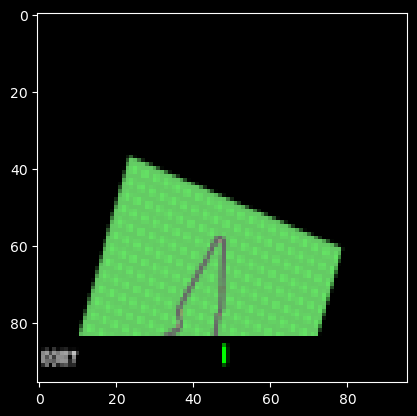

In [4]:
obs, info = env.reset()

plt.imshow(obs)

In [10]:
pos = env.unwrapped.car.hull.position
angle = env.unwrapped.car.hull.angle
print("car position:", float(pos[0]), float(pos[1]), "angle:", float(angle))

car position: 219.62435913085938 -54.03743362426758 angle: -0.09499789029359818

### DQN on Discrete CarRacing: what this does

1. Builds a **discrete-action** CarRacing environment (`continuous=False`).  
2. Wraps it with **Monitor** logging (episode rewards over time).  
3. Trains a **DQN (CnnPolicy)** model on pixel input.  
4. Loads logged rewards and plots the **learning curve** (episode reward vs timesteps).

This is intentionally minimal and easy to modify.

In [1]:
# Minimal DQN training on discrete CarRacing + learning curve
from pathlib import Path
import re

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.vec_env import VecTransposeImage

# In discrete mode, action space is Discrete(5)
# (noop, left, right, gas, brake)
def make_discrete_env():
    return gym.make(
        "CarRacing-v3",
        render_mode="rgb_array",
        continuous=False,
        lap_complete_percent=0.95,
        domain_randomize=False,
    )

log_dir = Path("./logs/dqn_discrete")
log_dir.mkdir(parents=True, exist_ok=True)

checkpoint_dir = Path("./checkpoints/dqn_discrete")
checkpoint_dir.mkdir(parents=True, exist_ok=True)
checkpoint_prefix = "dqn_carracing_step"
checkpoint_every_steps = 25_000

target_total_timesteps = 300_000

def checkpoint_step(path: Path) -> int:
    try:
        return int(path.stem.rsplit("_", 1)[-1])
    except ValueError:
        return -1

venv = make_vec_env(
    make_discrete_env,
    n_envs=1,
    monitor_dir=str(log_dir),
    seed=42,
)
venv = VecTransposeImage(venv)  # HWC -> CHW for CnnPolicy

device = "mps" if torch.backends.mps.is_available() else "cpu"

latest_checkpoint = max(
    checkpoint_dir.glob(f"{checkpoint_prefix}_*.zip"),
    key=checkpoint_step,
    default=None,
)

if latest_checkpoint is not None and checkpoint_step(latest_checkpoint) >= 0:
    print(f"Resuming from checkpoint: {latest_checkpoint}")
    model = DQN.load(str(latest_checkpoint), env=venv, device=device)

    replay_buffer_path = checkpoint_dir / f"{latest_checkpoint.stem}_replay_buffer.pkl"
    if replay_buffer_path.exists():
        model.load_replay_buffer(str(replay_buffer_path))
        print(f"Loaded replay buffer: {replay_buffer_path}")
    else:
        print("Replay buffer file not found for this checkpoint; continuing without it.")
else:
    print("No checkpoint found. Starting a new training run.")
    model = DQN(
        policy="CnnPolicy",
        env=venv,
        learning_rate=1e-4,
        buffer_size=30_000,
        learning_starts=5_000,
        batch_size=64,
        train_freq=4,
        target_update_interval=2_000,
        exploration_fraction=0.35,
        exploration_final_eps=0.02,
        optimize_memory_usage=True,
        replay_buffer_kwargs={"handle_timeout_termination": False},
        verbose=1,
        tensorboard_log="./tb_logs",
        seed=42,
        device=device,
    )

checkpoint_callback = CheckpointCallback(
    save_freq=max(checkpoint_every_steps // venv.num_envs, 1),
    save_path=str(checkpoint_dir),
    name_prefix=checkpoint_prefix,
    save_replay_buffer=True,
    save_vecnormalize=False,
)

current_steps = int(model.num_timesteps)
remaining_timesteps = max(0, target_total_timesteps - current_steps)

print(f"Device: {device}")
print(f"Current steps: {current_steps}, target: {target_total_timesteps}, remaining: {remaining_timesteps}")

if remaining_timesteps > 0:
    model.learn(
        total_timesteps=remaining_timesteps,
        reset_num_timesteps=False,
        progress_bar=True,
        callback=checkpoint_callback,
    )
else:
    print("Target already reached. Increase target_total_timesteps to continue training.")

model.save("dqn_carracing_discrete")
model.save_replay_buffer("dqn_carracing_discrete_replay_buffer.pkl")
venv.close()

# Learning curve from Monitor logs
x, y = ts2xy(load_results(str(log_dir)), "timesteps")

if len(y) == 0:
    print("No episode rewards logged yet. Train for more timesteps.")
else:
    window = 20
    if len(y) >= window:
        y_smooth = np.convolve(y, np.ones(window) / window, mode="valid")
        x_smooth = x[window - 1 :]
    else:
        y_smooth = y
        x_smooth = x

    plt.figure(figsize=(8, 4))
    plt.plot(x, y, alpha=0.25, label="Episode reward")
    plt.plot(x_smooth, y_smooth, linewidth=2, label=f"Moving avg ({window})")
    plt.xlabel("Timesteps")
    plt.ylabel("Episode reward")
    plt.title("DQN on CarRacing-v3 (discrete)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


objc[5391]: Class SDLApplication is implemented in both /opt/homebrew/Caskroom/miniforge/base/envs/gym/lib/python3.10/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x15a414890) and /opt/homebrew/Caskroom/miniforge/base/envs/gym/lib/python3.10/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x15c0912c8). One of the two will be used. Which one is undefined.
objc[5391]: Class SDLAppDelegate is implemented in both /opt/homebrew/Caskroom/miniforge/base/envs/gym/lib/python3.10/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x15a4148e0) and /opt/homebrew/Caskroom/miniforge/base/envs/gym/lib/python3.10/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x15c091318). One of the two will be used. Which one is undefined.
objc[5391]: Class SDLTranslatorResponder is implemented in both /opt/homebrew/Caskroom/miniforge/base/envs/gym/lib/python3.10/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x15a414958) and /opt/homebrew/Caskroom/miniforge/base/envs/gym/lib/python3.10/site-packages/pygame/.dyli

No checkpoint found. Starting a new training run.
Using mps device
Device: mps
Current steps: 0, target: 300000, remaining: 300000
Logging to ./tb_logs/DQN_4


/opt/homebrew/Caskroom/miniforge/base/envs/gym/lib/python3.10/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1e+03    |
|    ep_rew_mean      | -56.3    |
|    exploration_rate | 0.963    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 198      |
|    time_elapsed     | 20       |
|    total_timesteps  | 4000     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1e+03    |
|    ep_rew_mean      | -57.9    |
|    exploration_rate | 0.925    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 154      |
|    time_elapsed     | 51       |
|    total_timesteps  | 8000     |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 5.17e-05 |
|    n_updates        | 749      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean    

KeyboardInterrupt: 

In [ ]:
# Play one episode with the latest trained DQN agent checkpoint
from pathlib import Path
import re

import gymnasium as gym
import torch
from gymnasium.wrappers import RecordVideo
from IPython.display import Video, display
from stable_baselines3 import DQN

MODEL_PATH = "dqn_carracing_discrete"  # fallback: loads dqn_carracing_discrete.zip
CHECKPOINT_PREFIX = "dqn_carracing_step"
CHECKPOINT_DIR_CANDIDATES = [
    Path("./checkpoints/dqn_discrete"),
    Path("./CarRacing/checkpoints/dqn_discrete"),
]
LIVE_WINDOW = True  # True: open a game window, False: save and display mp4 in notebook
MAX_STEPS = 2_000

def checkpoint_step(path: Path) -> int:
    match = re.search(r"_(\d+)_steps$", path.stem)
    return int(match.group(1)) if match else -1

def latest_checkpoint_file(prefix: str) -> Path | None:
    files = []
    for directory in CHECKPOINT_DIR_CANDIDATES:
        if directory.exists():
            files.extend(directory.glob(f"{prefix}_*_steps.zip"))
    return max(files, key=checkpoint_step, default=None)

latest_checkpoint = latest_checkpoint_file(CHECKPOINT_PREFIX)

if latest_checkpoint is not None and checkpoint_step(latest_checkpoint) >= 0:
    model_to_load = str(latest_checkpoint)
else:
    model_to_load = MODEL_PATH

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Loading model: {model_to_load}")
print(f"Inference device: {device}")

if LIVE_WINDOW:
    env_play = gym.make(
        "CarRacing-v3",
        render_mode="human",
        continuous=False,
        lap_complete_percent=0.95,
        domain_randomize=False,
    )
    model_play = DQN.load(model_to_load, device=device)

    obs, info = env_play.reset(seed=123)
    ep_reward = 0.0

    for _ in range(MAX_STEPS):
        action, _ = model_play.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env_play.step(action)
        ep_reward += reward
        if terminated or truncated:
            break

    env_play.close()
    print(f"Episode reward (human render): {ep_reward:.1f}")
else:
    video_dir = Path("./videos/agent_play")
    video_dir.mkdir(parents=True, exist_ok=True)

    env_play = gym.make(
        "CarRacing-v3",
        render_mode="rgb_array",
        continuous=False,
        lap_complete_percent=0.95,
        domain_randomize=False,
    )
    env_play = RecordVideo(
        env_play,
        video_folder=str(video_dir),
        episode_trigger=lambda episode_id: True,
        disable_logger=True,
    )
    model_play = DQN.load(model_to_load, device=device)

    obs, info = env_play.reset(seed=123)
    ep_reward = 0.0

    for _ in range(MAX_STEPS):
        action, _ = model_play.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env_play.step(action)
        ep_reward += reward
        if terminated or truncated:
            break

    env_play.close()

    latest_video = sorted(video_dir.glob("*.mp4"))[-1]
    print(f"Episode reward (recorded): {ep_reward:.1f}")
    print(f"Saved video: {latest_video}")
    display(Video(str(latest_video), embed=True))

Loading model: checkpoints/dqn_discrete/dqn_carracing_step_300000_steps.zip
Inference device: mps


2026-04-28 00:48:12.275 python[14844:778690] +[IMKClient subclass]: chose IMKClient_Legacy
2026-04-28 00:48:12.275 python[14844:778690] +[IMKInputSession subclass]: chose IMKInputSession_Legacy


Episode reward (human render): 778.9


: 

### Continuous actions + 3 discount factors (fast experiments)

This section trains a **continuous-action** agent on `CarRacing-v3` with three values of $\gamma$ (including 0.9).
Experiments are **10-20x shorter** by design: fewer timesteps, shorter episodes, and smaller observations.

Using mps device


/opt/homebrew/Caskroom/miniforge/base/envs/gym/lib/python3.10/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 2.77GB > 2.30GB
  warnings.warn(


Training SAC gamma=0.85 on device=mps
Logging to ./tb_logs/SAC_1


/opt/homebrew/Caskroom/miniforge/base/envs/gym/lib/python3.10/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 150      |
|    ep_rew_mean     | 2.11     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 190      |
|    time_elapsed    | 3        |
|    total_timesteps | 600      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 150      |
|    ep_rew_mean     | 1.34     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 74       |
|    time_elapsed    | 16       |
|    total_timesteps | 1200     |
| train/             |          |
|    actor_loss      | -3.95    |
|    critic_loss     | 0.946    |
|    ent_coef        | 0.942    |
|    ent_coef_loss   | -0.301   |
|    learning_rate   | 0.0003   |
|    n_updates       | 199      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_me

...

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 150      |
|    ep_rew_mean     | 2.11     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 193      |
|    time_elapsed    | 3        |
|    total_timesteps | 600      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 150      |
|    ep_rew_mean     | 1.34     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 83       |
|    time_elapsed    | 14       |
|    total_timesteps | 1200     |
| train/             |          |
|    actor_loss      | -4.09    |
|    critic_loss     | 0.962    |
|    ent_coef        | 0.942    |
|    ent_coef_loss   | -0.301   |
|    learning_rate   | 0.0003   |
|    n_updates       | 199      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_me

Using mps device
Training SAC gamma=0.99 on device=mps
Logging to ./tb_logs/SAC_3


/opt/homebrew/Caskroom/miniforge/base/envs/gym/lib/python3.10/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/opt/homebrew/Caskroom/miniforge/base/envs/gym/lib/python3.10/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 2.77GB > 1.65GB
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 150      |
|    ep_rew_mean     | 2.11     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 195      |
|    time_elapsed    | 3        |
|    total_timesteps | 600      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 150      |
|    ep_rew_mean     | 1.34     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 84       |
|    time_elapsed    | 14       |
|    total_timesteps | 1200     |
| train/             |          |
|    actor_loss      | -4.36    |
|    critic_loss     | 0.97     |
|    ent_coef        | 0.942    |
|    ent_coef_loss   | -0.301   |
|    learning_rate   | 0.0003   |
|    n_updates       | 199      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_me

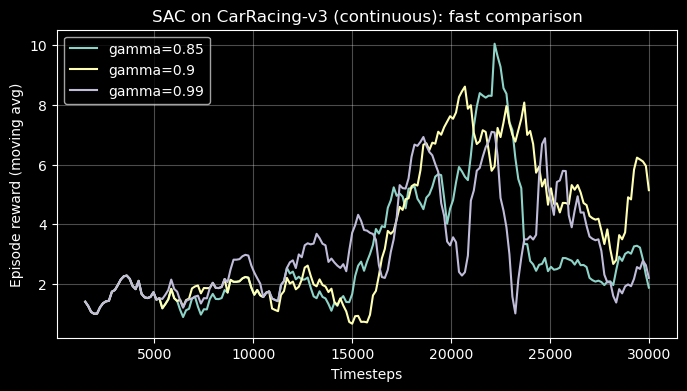

In [8]:
# Fast SAC training on continuous CarRacing with 3 gammas
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from stable_baselines3 import SAC
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.vec_env import VecTransposeImage


def make_continuous_env():
    env = gym.make(
        "CarRacing-v3",
        render_mode="rgb_array",
        continuous=True,
        lap_complete_percent=0.15,  # end episodes earlier
        domain_randomize=False,
        max_episode_steps=150,  # shorter episodes for speed
    )
    return env


device = "mps" if torch.backends.mps.is_available() else "cpu"
gammas = [0.85, 0.90, 0.99]
total_timesteps = 30_000  # ~10x shorter vs 300k discrete run
seed = 42

results = {}

for gamma in gammas:
    gamma_tag = f"{gamma:.2f}".replace(".", "_")
    log_dir = Path(f"./logs/sac_continuous_gamma_{gamma_tag}")
    log_dir.mkdir(parents=True, exist_ok=True)

    venv = make_vec_env(
        make_continuous_env,
        n_envs=1,
        monitor_dir=str(log_dir),
        seed=seed,
    )
    venv = VecTransposeImage(venv)
    policy_kwargs = {"features_extractor_kwargs": {"features_dim": 128}}

    model = SAC(
        policy="CnnPolicy",
        env=venv,
        gamma=gamma,
        learning_rate=3e-4,
        buffer_size=50_000,
        learning_starts=1_000,
        batch_size=64,
        train_freq=1,
        gradient_steps=1,
        ent_coef="auto",
        policy_kwargs=policy_kwargs,
        verbose=1,
        tensorboard_log="./tb_logs",
        seed=seed,
        device=device,
    )

    print(f"Training SAC gamma={gamma} on device={device}")
    model.learn(
        total_timesteps=total_timesteps,
        progress_bar=True,
    )
    model.save(f"sac_carracing_continuous_gamma_{gamma_tag}")
    venv.close()

    x, y = ts2xy(load_results(str(log_dir)), "timesteps")
    results[gamma] = (x, y)

# Plot learning curves for all gammas
plt.figure(figsize=(8, 4))
for gamma, (x, y) in results.items():
    if len(y) == 0:
        continue
    window = 10
    if len(y) >= window:
        y_smooth = np.convolve(y, np.ones(window) / window, mode="valid")
        x_smooth = x[window - 1 :]
    else:
        y_smooth = y
        x_smooth = x
    plt.plot(x_smooth, y_smooth, label=f"gamma={gamma}")

plt.title("SAC on CarRacing-v3 (continuous): fast comparison")
plt.xlabel("Timesteps")
plt.ylabel("Episode reward (moving avg)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# Play one episode with a trained SAC agent (continuous actions)
import gymnasium as gym
import torch
from stable_baselines3 import SAC
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecTransposeImage

MODEL_GAMMA = 0.90  # choose from: 0.85, 0.90, 0.99
MODEL_TAG = f"{MODEL_GAMMA:.2f}".replace(".", "_")
MODEL_PATH = f"sac_carracing_continuous_gamma_{MODEL_TAG}"
MAX_STEPS = 300

def make_play_env():
    env = gym.make(
        "CarRacing-v3",
        render_mode="human",
        continuous=True,
        lap_complete_percent=0.15,
        domain_randomize=False,
        max_episode_steps=150,
    )
    return env


device = "mps" if torch.backends.mps.is_available() else "cpu"
venv = make_vec_env(make_play_env, n_envs=1, seed=123)
venv = VecTransposeImage(venv)

model = SAC.load(MODEL_PATH, env=venv, device=device)
obs = venv.reset()

ep_reward = 0.0
for _ in range(MAX_STEPS):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, dones, infos = venv.step(action)
    ep_reward += float(reward[0])
    if dones[0]:
        break

venv.close()
print(f"Episode reward (human render): {ep_reward:.1f}")

/opt/homebrew/Caskroom/miniforge/base/envs/gym/lib/python3.10/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 2.77GB > 2.26GB
  warnings.warn(
2026-04-28 00:55:07.856 python[14877:780091] +[IMKClient subclass]: chose IMKClient_Legacy
2026-04-28 00:55:07.856 python[14877:780091] +[IMKInputSession subclass]: chose IMKInputSession_Legacy


Episode reward (human render): 2.7


: 